# Contact Prediction on MSA Hits: 7BNY

Hypothesis: feeding the model homologous sequences to 7BNY (rather than 7BNY itself) preserves the structural signal
and may even improve contact prediction (the model learns from sequence patterns common to the family,
and homologs sometimes give cleaner signals).

Setup:
* MSA contains a query construct, the 7BNY chain, and 11 BLAST hits (mostly full polyproteins).
* The 7BNY chain in the MSA includes construct tags (`SPNPLDVSK` + 132 structure residues + `GSKHHHHHH`).
* For each hit we keep only the residues aligning within the 132 structure-residue columns —
  i.e. anything completely N- or C-terminal to the actual 7BNY structure region is dropped.
* Each hit's compact sequence is fed through the model. Predicted contacts are
  mapped from prompt positions back to 7BNY positions via the alignment, then
  scored against the 7BNY ground truth contacts.

In [1]:
# Config
PDB_ID = "7BNY"
ALIGNMENT_PATH = "/home/bizon/Dropbox/OpenAthena/projects/202604-LlamaFold/inference-experiments/7bny_alignments.aln"

CONTACT_DISTANCE_CUTOFF = 4.0
BIN_EDGES = [4.0, 12.0]
MAX_NEW_TOKENS = 3440
N_ROLLOUTS = 10
DEVICE = "cuda"

HF_REPO = "timodonnell/LlamaFold-experiments"
HF_SUBFOLDER = "exp5.ethereal-galaxy-3"
WORK_DIR = "./msa_work"

# Persisted-rollouts settings: re-use saved generations to iterate on plots without rerunning the model.
# Set USE_SAVED_ROLLOUTS=False to regenerate (and overwrite the saved file).
ROLLOUTS_PATH = "rollouts/visualize_contacts_msa_7bny.json"
USE_SAVED_ROLLOUTS = True

In [2]:
# Download checkpoint (skipped if we're going to load saved rollouts).
import os
from pathlib import Path

if USE_SAVED_ROLLOUTS and os.path.exists(ROLLOUTS_PATH):
    CHECKPOINT_PATH = None
    print(f"Skipping checkpoint download — will load saved rollouts from {ROLLOUTS_PATH}")
else:
    from huggingface_hub import snapshot_download
    ckpt_root = snapshot_download(repo_id=HF_REPO, allow_patterns=[f"{HF_SUBFOLDER}/*"])
    exp_dir = Path(ckpt_root) / HF_SUBFOLDER
    ckpt_subdirs = sorted(exp_dir.glob("checkpoint-*"))
    if (exp_dir / "config.json").exists():
        CHECKPOINT_PATH = exp_dir
    elif ckpt_subdirs:
        CHECKPOINT_PATH = ckpt_subdirs[-1]
    else:
        raise FileNotFoundError(f"No checkpoint under {exp_dir}")
    print(f"Checkpoint: {CHECKPOINT_PATH}")
    assert (CHECKPOINT_PATH / "config.json").exists()

/home/bizon/git/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 109226.67it/s]

Checkpoint: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/0d7f58337cf20bdafcb76f0436aa3befd42a06e6/exp5.ethereal-galaxy-3/checkpoint-125500


In [3]:
# Imports + helpers
import os
import re
import tempfile
import time
from collections import Counter

import numpy as np
import torch
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from scipy.spatial import KDTree
from transformers import LlamaForCausalLM

from experiments.exp5_contact_prediction.src.data import AMINO_ACIDS, VALID_ATOMS
from experiments.exp5_contact_prediction.src.train import (
    create_tokenizer, parse_generated_contacts, check_atom_validity,
)

AA_3_TO_1 = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C",
    "GLN": "Q", "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I",
    "LEU": "L", "LYS": "K", "MET": "M", "PHE": "F", "PRO": "P",
    "SER": "S", "THR": "T", "TRP": "W", "TYR": "Y", "VAL": "V",
}
AA_1_TO_3 = {v: k for k, v in AA_3_TO_1.items()}
STANDARD_AAS = set(AA_1_TO_3)
NONSTANDARD_AA_MAP = {
    "MSE": "MET", "CSE": "CYS", "SEC": "CYS", "HYP": "PRO",
    "TPO": "THR", "SEP": "SER", "PTR": "TYR",
}
os.makedirs(WORK_DIR, exist_ok=True)

def assign_bin(d):
    return "bin_lt4" if d < BIN_EDGES[0] else ("bin_4_12" if d < BIN_EDGES[1] else "bin_gt12")

def parse_pdb_structure(pdb_id):
    path = rcsb.fetch(pdb_id, "cif", tempfile.gettempdir())
    cif = pdbx.CIFFile.read(path)
    atoms = pdbx.get_structure(cif.block, model=1)
    first_chain = atoms.chain_id[0]
    chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]
    unique_res = sorted(set(chain_atoms.res_id))
    sequence_raw = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]
    sequence = []
    for aa in sequence_raw:
        if aa in set(AMINO_ACIDS):
            sequence.append(aa)
        elif aa in NONSTANDARD_AA_MAP:
            sequence.append(NONSTANDARD_AA_MAP[aa])
        else:
            raise ValueError(f"Unknown AA: {aa}")
    return chain_atoms, sequence, first_chain, unique_res

def compute_gt_contacts(chain_atoms, sequence, unique_res, rng_seed=42):
    coords = chain_atoms.coord
    atom_names = chain_atoms.atom_name
    atom_res_ids = chain_atoms.res_id
    res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}
    all_known = set()
    for aa in VALID_ATOMS:
        all_known.update(VALID_ATOMS[aa])
    tree = KDTree(coords)
    raw = []
    for i, j in tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF):
        ri, rj = atom_res_ids[i], atom_res_ids[j]
        pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
        if pi is None or pj is None or abs(pi - pj) < 2: continue
        ai, aj = str(atom_names[i]), str(atom_names[j])
        if ai not in all_known or aj not in all_known: continue
        aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
        if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]: continue
        if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]: continue
        d = float(np.linalg.norm(coords[i] - coords[j]))
        if pi > pj:
            raw.append((pj, pi, aj, ai, d))
        else:
            raw.append((pi, pj, ai, aj, d))
    best = {}
    for c in raw:
        k = (c[0], c[1])
        if k not in best or c[4] < best[k][4]:
            best[k] = c
    rng = np.random.RandomState(rng_seed)
    items = list(best.values())
    rng.shuffle(items)
    return [(False, p1, p2, a1, a2, assign_bin(d)) for p1, p2, a1, a2, d in items]

def build_prompt(sequence_3letter):
    seq_tokens = " ".join(f"<{aa}>" for aa in sequence_3letter)
    return f"<random-3-bins> <begin_sequence> {seq_tokens} <begin_contacts>"

def seq_identity(a, b):
    """Identity over positions where both have non-gap residues.
    a, b are aligned 1-letter strings of the same length (gaps allowed)."""
    assert len(a) == len(b)
    matched = total = 0
    for x, y in zip(a, b):
        if x == "-" or y == "-":
            continue
        total += 1
        if x == y:
            matched += 1
    return matched / total if total else 0.0

print("helpers ready")

helpers ready


In [4]:
# Load model + tokenizer (skipped when we're loading saved rollouts).
if CHECKPOINT_PATH is None:
    print("Skipping model load — will load saved rollouts later")
    model = tokenizer = end_token_id = None

    def run_generation(prompt, do_sample=False):
        raise RuntimeError("Model not loaded. Set USE_SAVED_ROLLOUTS=False (and re-run cells 2,4,8) to regenerate.")
else:
    print(f"Loading: {CHECKPOINT_PATH}")
    tokenizer = create_tokenizer()
    model = LlamaForCausalLM.from_pretrained(str(CHECKPOINT_PATH), torch_dtype=torch.bfloat16).to(DEVICE).eval()
    end_token_id = tokenizer.convert_tokens_to_ids("<end>")
    print(f"Model: {sum(p.numel() for p in model.parameters()):,} params")

    def run_generation(prompt, do_sample=False):
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        gk = dict(max_new_tokens=MAX_NEW_TOKENS,
                  pad_token_id=tokenizer.pad_token_id,
                  eos_token_id=end_token_id)
        if do_sample:
            gk.update(do_sample=True, temperature=1.0, top_k=0)
        else:
            gk.update(do_sample=False)
        t0 = time.time()
        with torch.no_grad():
            out = model.generate(**inputs, **gk)
        elapsed = time.time() - t0
        gen_ids = out[0][inputs["input_ids"].shape[1]:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
        contacts, valid, plddt = parse_generated_contacts(gen_text.split())
        return contacts, valid, plddt, elapsed

Loading: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/0d7f58337cf20bdafcb76f0436aa3befd42a06e6/exp5.ethereal-galaxy-3/checkpoint-125500


Loading weights:   0%|          | 0/147 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/147 [00:00<00:00, 24818.37it/s, Materializing param=lm_head.weight]

Loading weights:   1%|          | 1/147 [00:00<00:00, 3024.01it/s, Materializing param=lm_head.weight] 

Loading weights:   1%|▏         | 2/147 [00:00<00:01, 107.74it/s, Materializing param=model.embed_tokens.weight]

...

Loading weights:  99%|█████████▉| 146/147 [00:00<00:00, 438.53it/s, Materializing param=model.layers.15.self_attn.v_proj.weight]

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 438.53it/s, Materializing param=model.norm.weight]                      

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 438.53it/s, Materializing param=model.norm.weight]

Loading weights: 100%|██████████| 147/147 [00:00<00:00, 830.31it/s, Materializing param=model.norm.weight]

Model: 984,528,896 params


In [5]:
# Parse 7BNY structure
chain_atoms, target_seq_3letter, chain_id, unique_res = parse_pdb_structure(PDB_ID)
target_seq_1letter = "".join(AA_3_TO_1[aa] for aa in target_seq_3letter)
target_len = len(target_seq_3letter)
gt_contacts = compute_gt_contacts(chain_atoms, target_seq_3letter, unique_res)
gt_pair_set = {(c[1], c[2]) for c in gt_contacts}
print(f"{PDB_ID}: {target_len} residues, chain {chain_id}, {len(gt_pair_set)} GT contacts")
print(f"Target sequence: {target_seq_1letter}")

7BNY: 132 residues, chain A, 347 GT contacts
Target sequence: TYPTLHILLQFNHRGLEARIFRHGQLWAETHAEVVLRSKTKQISFLSNGSYPSMDATTPLNPWKSTYQAVLRAEPHRVTMDVYHKRIRPFRLPLVQKEWRTCEENVFGLYHVFETHYAGYFSDLLIHDVETN


In [6]:
# Parse alignment, locate target columns, extract per-hit compact sequences
def parse_aln(path):
    """Return list of (header, aligned_row_string). Whitespace within sequence lines stripped."""
    records = []
    header, lines = None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(lines)))
                header = line[1:].strip()
                lines = []
            else:
                lines.append(re.sub(r"\s", "", line))
        if header is not None:
            records.append((header, "".join(lines)))
    return records

records = parse_aln(ALIGNMENT_PATH)
aln_width = len(records[0][1])
for h, s in records:
    assert len(s) == aln_width, f"width mismatch: {h}: {len(s)} != {aln_width}"
print(f"{len(records)} records, width={aln_width}")

# Locate the 7BNY chain entry
target_record_idx = None
for i, (h, _) in enumerate(records):
    if PDB_ID in h.upper():
        target_record_idx = i
        break
assert target_record_idx is not None, f"No row containing {PDB_ID} in headers"
target_header, target_row = records[target_record_idx]
print(f"Target row: idx={target_record_idx} header={target_header[:60]}")

# Find columns of the structure within target_row.
# target_row may include construct tags around the structure sequence.
non_gap = [(col, ch) for col, ch in enumerate(target_row) if ch != "-"]
non_gap_str = "".join(ch for _, ch in non_gap)
struct_offset = non_gap_str.find(target_seq_1letter)
assert struct_offset >= 0, (
    f"target structure sequence not found in target row.\n"
    f"non_gap row: {non_gap_str}\nstructure : {target_seq_1letter}")
struct_cols = [non_gap[struct_offset + i][0] for i in range(target_len)]
first_col, last_col = struct_cols[0], struct_cols[-1]
print(f"Structure occupies non-gap chars [{struct_offset}, {struct_offset + target_len}) in target row")
print(f"Structure columns: [{first_col}, {last_col}], width = {last_col - first_col + 1}")

# For each non-target record, pull residues at struct_cols. Skip ambiguous/non-standard letters.
def extract_hit(row, struct_cols):
    compact = []
    pos_map = []  # 7BNY position (1-indexed) for each residue in compact
    skipped_nonstd = 0
    for i, col in enumerate(struct_cols):
        ch = row[col].upper()
        if ch == "-":
            continue
        if ch not in STANDARD_AAS:
            skipped_nonstd += 1
            continue
        compact.append(ch)
        pos_map.append(i + 1)  # 7BNY position is 1-indexed
    return "".join(compact), pos_map, skipped_nonstd

# Skip the query (synthetic construct) — we want biological homologs only.
# Also skip the target row (we'll handle it separately as the native baseline).
def is_query_construct(header):
    return header.lower().startswith("lcl|query")

hits = []
for i, (header, row) in enumerate(records):
    if i == target_record_idx or is_query_construct(header):
        continue
    compact, pos_map, skipped = extract_hit(row, struct_cols)
    # Identity vs target structure residues over positions where the hit has a residue
    aligned_target_chars = [target_seq_1letter[pos - 1] for pos in pos_map]
    n_match = sum(1 for c, t in zip(compact, aligned_target_chars) if c == t)
    identity = n_match / len(compact) if compact else 0.0
    short_label = header.split()[0]  # before first whitespace
    hits.append({
        "label": short_label,
        "header": header,
        "compact_1letter": compact,
        "pos_map": pos_map,
        "identity": identity,
        "coverage": len(pos_map) / target_len,
        "skipped_nonstd": skipped,
    })

# Add native as a baseline (full target sequence, identity mapping)
native_entry = {
    "label": "native",
    "header": f"native {PDB_ID}",
    "compact_1letter": target_seq_1letter,
    "pos_map": list(range(1, target_len + 1)),
    "identity": 1.0,
    "coverage": 1.0,
    "skipped_nonstd": 0,
}
variants = [native_entry] + hits

print(f"\n{len(variants)} variants total ({len(hits)} hits + 1 native)")
print(f"{'label':<30} {'len':>4} {'cov':>5} {'id':>5} {'nonstd':>7}")
for v in variants:
    print(f"{v['label']:<30} {len(v['compact_1letter']):>4} {v['coverage']:>5.0%} {v['identity']:>5.1%} {v['skipped_nonstd']:>7}")

13 records, width=2376
Target row: idx=1 header=pdb|7BNY|A  [organism=Mengo virus] [gcode=1]
Structure occupies non-gap chars [9, 141) in target row
Structure columns: [924, 1055], width = 132

12 variants total (11 hits + 1 native)
label                           len   cov    id  nonstd
native                          132  100% 100.0%       0
ref|NP_740406.1|                132  100% 78.0%       0
ref|NP_056777.1|                132  100% 78.0%       0
ref|YP_006383902.1|             132  100% 78.0%       0
gb|XOT37722.1|                  119   90% 85.7%       0
gb|WPV63283.1|                  132  100% 71.2%       0
gb|AGU38152.1|                  132  100% 68.9%       0
gb|QIM74091.1|                  132  100% 69.7%       0
gb|UYI58720.1|                  132  100% 68.2%       0
gb|WCD68998.1|                  132  100% 68.2%       0
gb|QGQ63620.1|                  132  100% 66.7%       0
gb|WCD68999.1|                  132  100% 67.4%       0


In [7]:
# Sanity check: visualize the target sequence and how hit residues line up
print(f"Target structure ({target_len} residues):")
print(target_seq_1letter)
print()
print("Per-position alignment (X = covered with matching aa, . = covered different aa, _ = not covered):")
for v in variants[:6]:
    if v["label"] == "native":
        continue
    pos_to_aa = dict(zip(v["pos_map"], v["compact_1letter"]))
    line = []
    for p in range(1, target_len + 1):
        aa = pos_to_aa.get(p)
        if aa is None:
            line.append("_")
        elif aa == target_seq_1letter[p - 1]:
            line.append(target_seq_1letter[p - 1])
        else:
            line.append(aa.lower())
    print(f"{v['label'][:28]:<30} {''.join(line)}")

Target structure (132 residues):
TYPTLHILLQFNHRGLEARIFRHGQLWAETHAEVVLRSKTKQISFLSNGSYPSMDATTPLNPWKSTYQAVLRAEPHRVTMDVYHKRIRPFRLPLVQKEWRTCEENVFGLYHVFETHYAGYFSDLLIHDVETN

Per-position alignment (X = covered with matching aa, . = covered different aa, _ = not covered):
ref|NP_740406.1|               TYPTLHvLiQFNHRGLEvRlFRHGhfWAETrAdViLRSKTKQvSFLSNGnYPSMDsraPwNPWKnTYQAVLRAEPcRVTMDiYyKRvRPFRLPLVQKEWpvrEENVFGLYriFnaHYAGYFaDLLIHDiETN
ref|NP_056777.1|               TYPTLHvLiQFNHRGLEvRlFRHGhfWAETrAdViLRSKTKQvSFLSNGnYPSMDsraPwNPWKnTYQAVLRAEPcRVTMDiYyKRvRPFRLPLVQKEWpvrEENVFGLYriFnaHYAGYFaDLLIHDiETN
ref|YP_006383902.1|            TYPTLHvLiQFNHRGLEvRlFRHGhfWAETrAdViLRSKTKQvSFLSNGnYPSMDsraPwNPWKnTYQAVLRAEPcRVTMDiYyKRvRPFRLPLVQKEWpvrEENVFGLYriFnaHYAGYFaDLLIHDiETN
gb|XOT37722.1|                 TYPTLyILmQFsHRGLEvRlFRHGQLWAETrAnVVLRSKTKQISFLnNGSYPSMDATTPwNPWrnTfQAVLRAEPHRVTMDiYHKRIRPFRLPLVQKEWRahEENiFGLYHiFETHYAG_____________
gb|WPV63283.1|                 TYPvLyILLQFsHvGLEARlFRrGdyWAsmHsdlVLRSrhKQISFLeN

In [8]:
# Run model on each variant: greedy + N_ROLLOUTS sampled rollouts.
# When USE_SAVED_ROLLOUTS=True and ROLLOUTS_PATH exists, just load the saved generations
# (so plot iterations don't pay for ~70 min of LLM rollouts).
import json

def save_rollouts(variants, path):
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    payload = {
        "schema_version": 1,
        "config": {
            "n_rollouts": N_ROLLOUTS,
            "max_new_tokens": MAX_NEW_TOKENS,
            "checkpoint": str(CHECKPOINT_PATH) if CHECKPOINT_PATH else None,
            "pdb_id": PDB_ID,
        },
        "variants": {},
    }
    for v in variants:
        payload["variants"][v["label"]] = {
            "header": v.get("header", v["label"]),
            "sequence_1letter": v["compact_1letter"],
            "pos_map": v["pos_map"],
            "identity": v["identity"],
            "coverage": v["coverage"],
            "greedy": {
                "contacts": [list(c) for c in v["greedy_contacts"]],
                "valid_grammar": v["greedy_valid"],
                "plddt": v["greedy_plddt"],
                "time_seconds": v["greedy_time"],
            },
            "rollouts": [
                {
                    "contacts": [list(c) for c in r],
                    "plddt": p,
                    "time_seconds": t,
                }
                for r, p, t in zip(v["rollouts"], v["rollout_plddts"], v["rollout_times"])
            ],
        }
    with open(path, "w") as f:
        json.dump(payload, f, indent=1)
    print(f"Saved {len(variants)} variants -> {path}")


def load_rollouts(variants, path):
    with open(path) as f:
        payload = json.load(f)
    by_label = {v["label"]: v for v in variants}
    loaded = []
    for label, data in payload["variants"].items():
        if label not in by_label:
            print(f"  WARNING: saved variant {label!r} not in current variants list; skipping")
            continue
        v = by_label[label]
        v["sequence_3letter"] = [AA_1_TO_3[c] for c in data["sequence_1letter"]]
        g = data["greedy"]
        v["greedy_contacts"] = [tuple(c) for c in g["contacts"]]
        v["greedy_valid"] = g["valid_grammar"]
        v["greedy_plddt"] = g["plddt"]
        v["greedy_time"] = g["time_seconds"]
        v["rollouts"] = [[tuple(c) for c in r["contacts"]] for r in data["rollouts"]]
        v["rollout_plddts"] = [r["plddt"] for r in data["rollouts"]]
        v["rollout_times"] = [r["time_seconds"] for r in data["rollouts"]]
        loaded.append(label)
    print(f"Loaded {len(loaded)} variants from {path}")


if USE_SAVED_ROLLOUTS and os.path.exists(ROLLOUTS_PATH):
    load_rollouts(variants, ROLLOUTS_PATH)
else:
    for v in variants:
        seq3 = [AA_1_TO_3[c] for c in v["compact_1letter"]]
        prompt = build_prompt(seq3)
        print(f"\n=== {v['label']} ({len(seq3)} residues, prompt {len(prompt.split())} toks) ===")
        t0 = time.time()
        g, gv, gp, gt = run_generation(prompt, do_sample=False)
        print(f"  greedy: {len(g)} contacts, valid={gv}, plddt={gp}, {gt:.1f}s")
        rollouts, plddts, times = [], [], []
        for r in range(N_ROLLOUTS):
            c, _, p, t = run_generation(prompt, do_sample=True)
            rollouts.append(c); plddts.append(p); times.append(t)
        print(f"  rollouts: {N_ROLLOUTS}x, avg {np.mean(times):.1f}s, total {time.time()-t0:.1f}s")
        v["sequence_3letter"] = seq3
        v["greedy_contacts"] = g
        v["greedy_valid"] = gv
        v["greedy_plddt"] = gp
        v["greedy_time"] = gt
        v["rollouts"] = rollouts
        v["rollout_plddts"] = plddts
        v["rollout_times"] = times
    save_rollouts(variants, ROLLOUTS_PATH)


=== native (132 residues, prompt 135 toks) ===


  greedy: 38 contacts, valid=True, plddt=None, 3.0s


  rollouts: 10x, avg 25.5s, total 258.2s

=== ref|NP_740406.1| (132 residues, prompt 135 toks) ===


  greedy: 44 contacts, valid=True, plddt=None, 2.9s


  rollouts: 10x, avg 28.1s, total 284.1s

=== ref|NP_056777.1| (132 residues, prompt 135 toks) ===


...

  rollouts: 10x, avg 30.3s, total 307.9s

=== gb|QGQ63620.1| (132 residues, prompt 135 toks) ===


  greedy: 54 contacts, valid=True, plddt=None, 3.6s


  rollouts: 10x, avg 26.9s, total 273.1s

=== gb|WCD68999.1| (132 residues, prompt 135 toks) ===


  greedy: 63 contacts, valid=True, plddt=None, 4.1s


  rollouts: 10x, avg 27.9s, total 283.5s
Saved 12 variants -> rollouts/visualize_contacts_msa_7bny.json


In [9]:
# Map predicted contacts from prompt-position space to 7BNY-position space, then score.
# Two scoring modes:
#   global  — denominator = all 7BNY GT contacts (penalises coverage gaps)
#   covered — denominator = GT contacts where both endpoints are present in the hit

def map_contacts_to_target(contacts, pos_map, target_len):
    """Map contacts (which use prompt 1-indexed positions) into 7BNY-coordinate residue pairs.
    Returns (target_contacts_list, n_dropped) where each entry is
    (is_corr, p1_target, p2_target, a1, a2, bin) with p1<p2."""
    out, dropped = [], 0
    n = len(pos_map)
    for c in contacts:
        is_corr, p1p, p2p, a1, a2, bn = c
        if p1p < 1 or p1p > n or p2p < 1 or p2p > n:
            dropped += 1
            continue
        t1, t2 = pos_map[p1p - 1], pos_map[p2p - 1]
        if t1 == t2:
            dropped += 1
            continue
        if t1 > t2:
            t1, t2 = t2, t1
            a1, a2 = a2, a1
        out.append((is_corr, t1, t2, a1, a2, bn))
    return out, dropped

def freq_matrix_in_target(rollouts_target, target_len):
    m = np.zeros((target_len, target_len), dtype=np.float32)
    for contacts in rollouts_target:
        seen = set()
        for c in contacts:
            if c[5] != "bin_lt4":
                continue
            key = (c[1], c[2])
            if key in seen:
                continue
            seen.add(key)
            i, j = c[1] - 1, c[2] - 1
            m[i, j] += 1
            m[j, i] += 1
    if rollouts_target:
        m /= len(rollouts_target)
    return m

def consensus_pairs(freq, target_len, threshold=0.5):
    out = set()
    for i in range(target_len):
        for j in range(i + 1, target_len):
            if freq[i, j] > threshold:
                out.add((i + 1, j + 1))
    return out

def covered_gt(pos_map, gt_pair_set):
    cov = set(pos_map)
    return {(a, b) for (a, b) in gt_pair_set if a in cov and b in cov}

for v in variants:
    pos_map = v["pos_map"]
    rollouts_t = []
    drops_total = 0
    for r in v["rollouts"]:
        mapped, dropped = map_contacts_to_target(r, pos_map, target_len)
        rollouts_t.append(mapped)
        drops_total += dropped
    v["rollouts_target"] = rollouts_t
    v["n_dropped_contacts"] = drops_total
    freq = freq_matrix_in_target(rollouts_t, target_len)
    v["freq_matrix"] = freq
    pred = consensus_pairs(freq, target_len, threshold=0.5)
    v["pred_pairs"] = pred
    cgt = covered_gt(pos_map, gt_pair_set)
    v["covered_gt"] = cgt
    v["global"] = {
        "n_pred": len(pred),
        "n_correct": len(pred & gt_pair_set),
        "precision": (len(pred & gt_pair_set) / len(pred)) if pred else 0.0,
        "recall": (len(pred & gt_pair_set) / len(gt_pair_set)) if gt_pair_set else 0.0,
    }
    v["covered"] = {
        "n_pred": len(pred & {(a, b) for (a, b) in pred if a in set(pos_map) and b in set(pos_map)}),
        "n_correct": len(pred & cgt),
        "precision": (len(pred & cgt) / len({p for p in pred if p[0] in set(pos_map) and p[1] in set(pos_map)})) if pred else 0.0,
        "recall": (len(pred & cgt) / len(cgt)) if cgt else 0.0,
        "n_covered_gt": len(cgt),
    }

# Summary table
print(f"{'Label':<30} {'Len':>4} {'Cov':>4} {'Id':>5} | {'GP':>5} {'GR':>5} {'NPr':>4} | {'CP':>5} {'CR':>5} {'CovGT':>5}")
print("-" * 100)
for v in variants:
    g, c = v["global"], v["covered"]
    print(f"{v['label'][:30]:<30} {len(v['compact_1letter']):>4} {v['coverage']:>4.0%} {v['identity']:>5.1%} | "
          f"{g['precision']:>4.0%} {g['recall']:>4.0%} {g['n_pred']:>4d} | "
          f"{c['precision']:>4.0%} {c['recall']:>4.0%} {c['n_covered_gt']:>5d}")
print("\nGP/GR = global precision/recall (vs all GT)  CP/CR = covered (vs GT pairs both endpoints in hit)")

Label                           Len  Cov    Id |    GP    GR  NPr |    CP    CR CovGT
----------------------------------------------------------------------------------------------------
native                          132 100% 100.0% |  65%  23%  123 |  65%  23%   347
ref|NP_740406.1|                132 100% 78.0% |  63%  26%  143 |  63%  26%   347
ref|NP_056777.1|                132 100% 78.0% |  65%  24%  127 |  65%  24%   347
ref|YP_006383902.1|             132 100% 78.0% |  69%  27%  137 |  69%  27%   347
gb|XOT37722.1|                  119  90% 85.7% |  63%  17%   95 |  63%  20%   306
gb|WPV63283.1|                  132 100% 71.2% |  49%  28%  196 |  49%  28%   347
gb|AGU38152.1|                  132 100% 68.9% |  44%  30%  235 |  44%  30%   347
gb|QIM74091.1|                  132 100% 69.7% |  50%  27%  191 |  50%  27%   347
gb|UYI58720.1|                  132 100% 68.2% |  52%  29%  189 |  52%  29%   347
gb|WCD68998.1|                  132 100% 68.2% |  56%  28%  175 |  56%  28

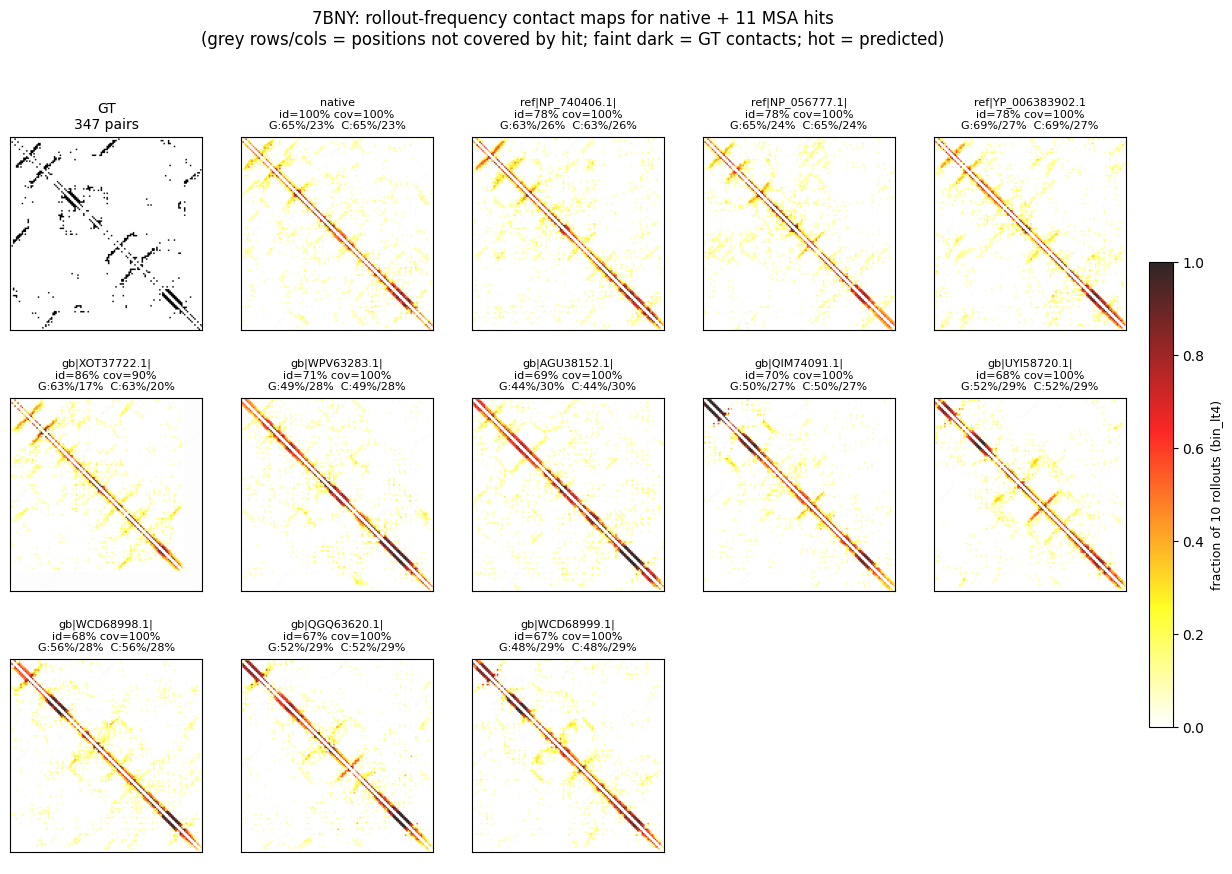

In [10]:
# Contact-map heatmap grid: GT + each variant in 7BNY coordinates.
%matplotlib inline
import matplotlib.pyplot as plt

def gt_matrix_from_pairs(pair_set, n):
    m = np.zeros((n, n), dtype=np.float32)
    for (a, b) in pair_set:
        m[a - 1, b - 1] = 1
        m[b - 1, a - 1] = 1
    return m

gt_matrix = gt_matrix_from_pairs(gt_pair_set, target_len)

n_panels = 1 + len(variants)
n_cols = 5
n_rows = (n_panels + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 3.2 * n_rows))
axes = np.atleast_2d(axes).ravel()

axes[0].imshow(gt_matrix, cmap="Greys", vmin=0, vmax=1, origin="upper")
axes[0].set_title(f"GT\n{len(gt_pair_set)} pairs", fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])

im = None
for i, v in enumerate(variants):
    ax = axes[i + 1]
    # Show coverage mask (rows/cols not covered are tinted gray)
    coverage = np.zeros((target_len, target_len), dtype=np.float32)
    cov = set(v["pos_map"])
    for p in range(target_len):
        coverage[p, :] = 1 if (p + 1) in cov else 0
        coverage[:, p] *= 1 if (p + 1) in cov else 0
    ax.imshow(np.where(coverage > 0, 0, 0.2), cmap="Greys", vmin=0, vmax=1, origin="upper", alpha=0.4)
    ax.imshow(np.where(gt_matrix > 0, 0.3, 0.0), cmap="Greys", vmin=0, vmax=1, origin="upper", alpha=0.45)
    im = ax.imshow(v["freq_matrix"], cmap="hot_r", vmin=0, vmax=1, origin="upper", alpha=0.85)
    g, c = v["global"], v["covered"]
    ax.set_title(f"{v['label'][:18]}\nid={v['identity']:.0%} cov={v['coverage']:.0%}\n"
                 f"G:{g['precision']:.0%}/{g['recall']:.0%}  C:{c['precision']:.0%}/{c['recall']:.0%}",
                 fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

for k in range(n_panels, len(axes)):
    axes[k].axis("off")
if im is not None:
    cbar = fig.colorbar(im, ax=axes[:n_panels].tolist(), fraction=0.02, pad=0.02)
    cbar.set_label(f"fraction of {N_ROLLOUTS} rollouts (bin_lt4)", fontsize=9)
fig.suptitle(f"{PDB_ID}: rollout-frequency contact maps for native + {len(variants) - 1} MSA hits\n"
             f"(grey rows/cols = positions not covered by hit; faint dark = GT contacts; hot = predicted)",
             fontsize=12, y=1.0)
plt.show()

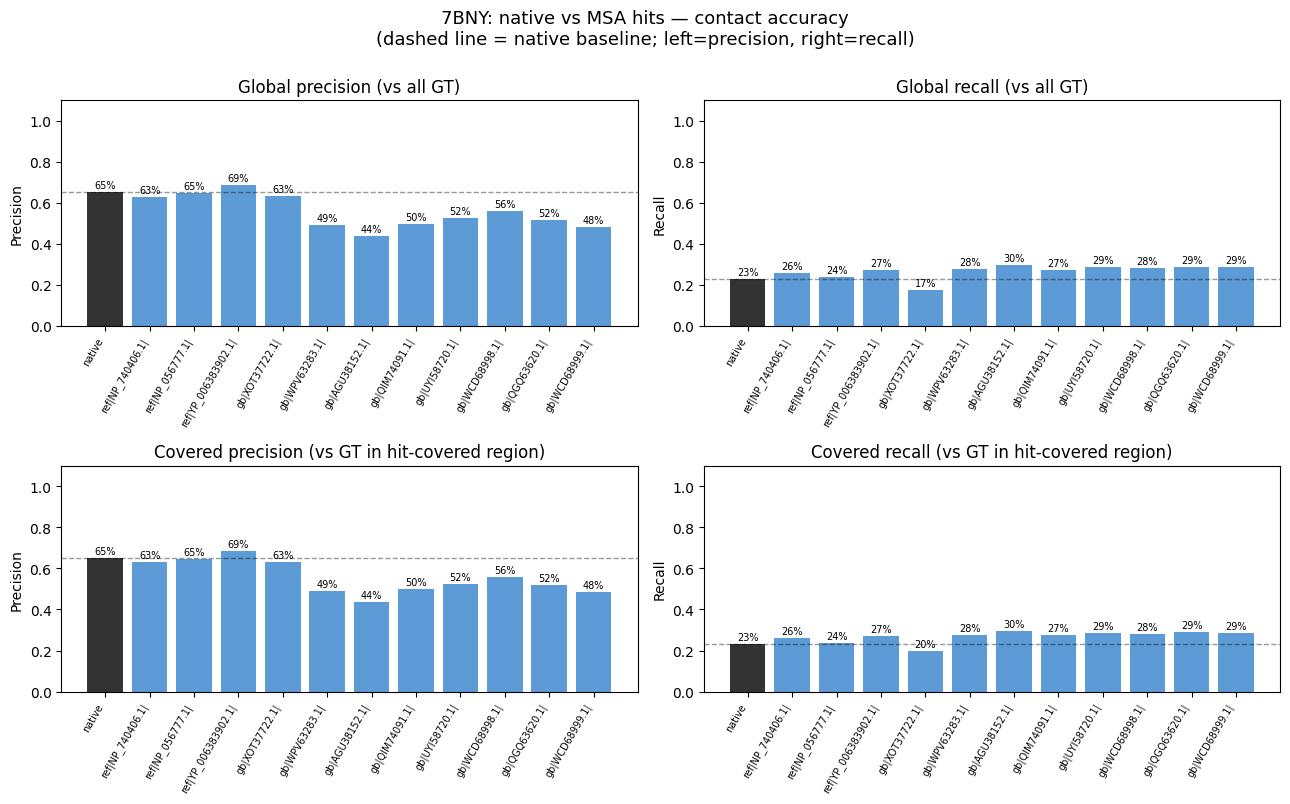

In [11]:
# Bar chart: precision/recall in both modes per variant
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
labels = [v["label"][:24] for v in variants]
x = np.arange(len(variants))
colors = ["#333333"] + ["#5C9BD5"] * (len(variants) - 1)

panels = [
    (axes[0, 0], "global", "precision", "Global precision (vs all GT)"),
    (axes[0, 1], "global", "recall",    "Global recall (vs all GT)"),
    (axes[1, 0], "covered", "precision", "Covered precision (vs GT in hit-covered region)"),
    (axes[1, 1], "covered", "recall",    "Covered recall (vs GT in hit-covered region)"),
]
for ax, mode, metric, title in panels:
    vals = [v[mode][metric] for v in variants]
    ax.bar(x, vals, color=colors)
    for i, val in enumerate(vals):
        ax.text(i, val + 0.01, f"{val:.0%}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric.capitalize())
    ax.set_title(title)
    ax.axhline(vals[0], color="black", linestyle="--", alpha=0.4, linewidth=1)
fig.suptitle(f"{PDB_ID}: native vs MSA hits — contact accuracy\n"
             f"(dashed line = native baseline; left=precision, right=recall)",
             fontsize=13, y=1.0)
plt.tight_layout()
plt.show()

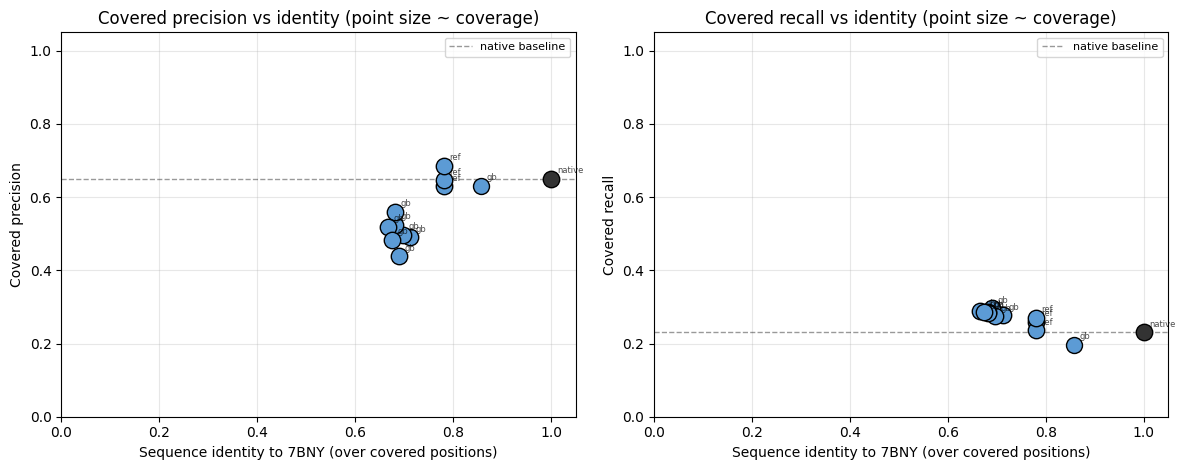

In [12]:
# Scatter: identity vs covered precision/recall (covered metrics are the fairest comparison
# because they remove the trivial coverage-induced recall penalty).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, metric, label in zip(axes, ["precision", "recall"], ["Covered precision", "Covered recall"]):
    xs = [v["identity"] for v in variants]
    ys = [v["covered"][metric] for v in variants]
    sizes = [60 + 80 * v["coverage"] for v in variants]
    colors = ["#333333"] + ["#5C9BD5"] * (len(variants) - 1)
    for i, v in enumerate(variants):
        ax.scatter(xs[i], ys[i], s=sizes[i], c=colors[i], edgecolors="black", zorder=3)
        ax.annotate(v["label"].split("|")[0][:15], (xs[i], ys[i]),
                    fontsize=6, alpha=0.7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlabel("Sequence identity to 7BNY (over covered positions)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs identity (point size ~ coverage)")
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)
    # Native horizontal line
    ax.axhline(ys[0], color="black", linestyle="--", alpha=0.4, linewidth=1, label="native baseline")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Ensemble across hits — does combining predictions across multiple homologs
# improve over native? Two strategies:
#  (a) average the per-variant rollout-frequency matrices
#  (b) union of pred_pairs across all hits
from copy import deepcopy

hit_variants = [v for v in variants if v["label"] != "native"]

# Average freq matrix across hits
avg_freq = np.zeros((target_len, target_len), dtype=np.float32)
for v in hit_variants:
    avg_freq += v["freq_matrix"]
avg_freq /= max(len(hit_variants), 1)

for thr in [0.3, 0.5, 0.7]:
    pred = consensus_pairs(avg_freq, target_len, threshold=thr)
    n_correct = len(pred & gt_pair_set)
    p = n_correct / len(pred) if pred else 0
    r = n_correct / len(gt_pair_set) if gt_pair_set else 0
    print(f"avg-freq @ thr={thr}: pred={len(pred)}, correct={n_correct}, P={p:.1%}, R={r:.1%}")

# Union of >0.5 consensus pairs
union_pred = set()
for v in hit_variants:
    union_pred |= v["pred_pairs"]
n_correct = len(union_pred & gt_pair_set)
p = n_correct / len(union_pred) if union_pred else 0
r = n_correct / len(gt_pair_set) if gt_pair_set else 0
print(f"\nunion of hit consensus(>0.5): pred={len(union_pred)}, correct={n_correct}, P={p:.1%}, R={r:.1%}")

# Voting: pair appears in K or more hits
hit_counter = Counter()
for v in hit_variants:
    hit_counter.update(v["pred_pairs"])
for k_min in [2, 3, 5, 7]:
    pred = {p for p, c in hit_counter.items() if c >= k_min}
    n_correct = len(pred & gt_pair_set)
    pp = n_correct / len(pred) if pred else 0
    rr = n_correct / len(gt_pair_set) if gt_pair_set else 0
    print(f"voting ≥{k_min} hits: pred={len(pred)}, correct={n_correct}, P={pp:.1%}, R={rr:.1%}")

print(f"\nNative baseline: P={variants[0]['global']['precision']:.1%}, R={variants[0]['global']['recall']:.1%}")

avg-freq @ thr=0.3: pred=267, correct=115, P=43.1%, R=33.1%
avg-freq @ thr=0.5: pred=170, correct=100, P=58.8%, R=28.8%
avg-freq @ thr=0.7: pred=106, correct=77, P=72.6%, R=22.2%

union of hit consensus(>0.5): pred=311, correct=129, P=41.5%, R=37.2%
voting ≥2 hits: pred=249, correct=111, P=44.6%, R=32.0%
voting ≥3 hits: pred=229, correct=109, P=47.6%, R=31.4%
voting ≥5 hits: pred=186, correct=104, P=55.9%, R=30.0%
voting ≥7 hits: pred=154, correct=97, P=63.0%, R=28.0%

Native baseline: P=65.0%, R=23.1%


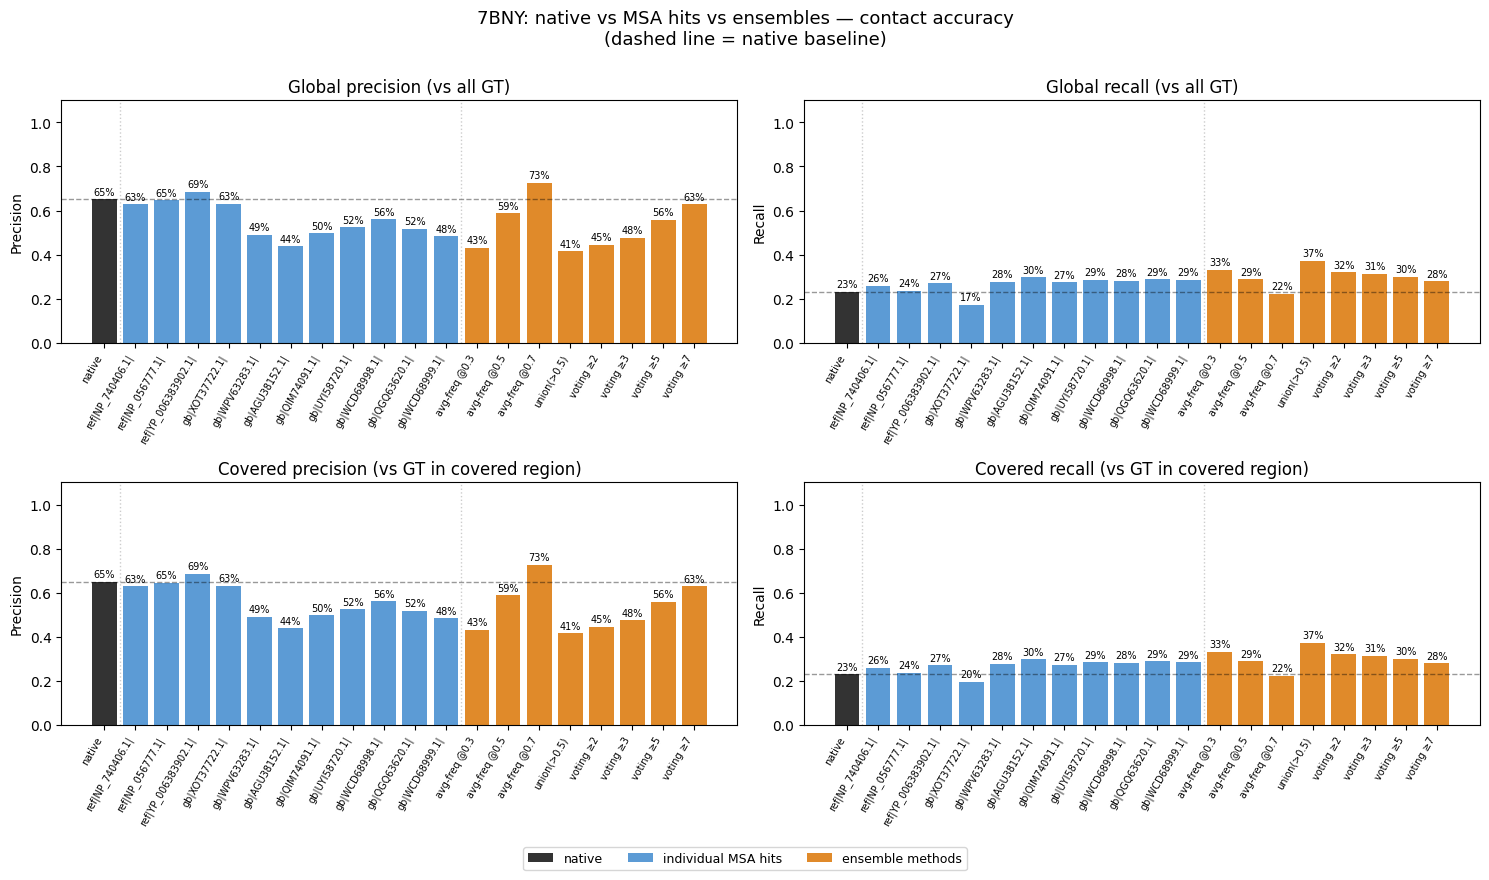

In [14]:
# Same 4-panel bar chart as before, but extended with ensemble methods.
# Ensemble "covered GT" = GT pairs where both endpoints are covered by at least one hit.
# (For this dataset coverage is ~100% so ensemble global ≈ covered, but we compute it for honesty.)
ensemble_cov_positions = set()
for v in hit_variants:
    ensemble_cov_positions.update(v["pos_map"])
ensemble_covered_gt_pairs = {
    (a, b) for (a, b) in gt_pair_set
    if a in ensemble_cov_positions and b in ensemble_cov_positions
}

def _score(pred, gt_pred_universe_pairs, covered_gt_pairs):
    """Compute global+covered metrics for a single ensemble pred set.
    pred is restricted to pairs both endpoints in ensemble coverage for the covered-* metrics."""
    n_pred = len(pred)
    n_correct = len(pred & gt_pair_set)
    pred_in_cov = {p for p in pred if p[0] in ensemble_cov_positions and p[1] in ensemble_cov_positions}
    n_correct_cov = len(pred_in_cov & covered_gt_pairs)
    return {
        "global": {
            "n_pred": n_pred,
            "n_correct": n_correct,
            "precision": n_correct / n_pred if n_pred else 0.0,
            "recall": n_correct / len(gt_pair_set) if gt_pair_set else 0.0,
        },
        "covered": {
            "n_pred": len(pred_in_cov),
            "n_correct": n_correct_cov,
            "precision": n_correct_cov / len(pred_in_cov) if pred_in_cov else 0.0,
            "recall": n_correct_cov / len(covered_gt_pairs) if covered_gt_pairs else 0.0,
        },
    }

# Build ensemble entries (in the same shape as a variant dict)
ensemble_rows = []

# avg-freq at multiple thresholds
for thr in [0.3, 0.5, 0.7]:
    pred = consensus_pairs(avg_freq, target_len, threshold=thr)
    s = _score(pred, gt_pair_set, ensemble_covered_gt_pairs)
    ensemble_rows.append({"label": f"avg-freq @{thr}", **s})

# Union of per-hit consensus(>0.5)
union_pred_set = set()
for v in hit_variants:
    union_pred_set |= v["pred_pairs"]
ensemble_rows.append({"label": "union(>0.5)", **_score(union_pred_set, gt_pair_set, ensemble_covered_gt_pairs)})

# Voting: pair appears in >= K hits
hit_counter = Counter()
for v in hit_variants:
    hit_counter.update(v["pred_pairs"])
for k_min in [2, 3, 5, 7]:
    pred = {p for p, c in hit_counter.items() if c >= k_min}
    s = _score(pred, gt_pair_set, ensemble_covered_gt_pairs)
    ensemble_rows.append({"label": f"voting ≥{k_min}", **s})

# Plot: same 4-panel layout as cell-11, but with ensemble bars appended in a different color.
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
all_rows = list(variants) + ensemble_rows
labels = [r["label"][:24] for r in all_rows]
x = np.arange(len(all_rows))
colors = (
    ["#333333"]                          # native
    + ["#5C9BD5"] * (len(variants) - 1)  # individual hits
    + ["#E08A2A"] * len(ensemble_rows)   # ensembles
)

native_idx = 0
panels = [
    (axes[0, 0], "global", "precision", "Global precision (vs all GT)"),
    (axes[0, 1], "global", "recall",    "Global recall (vs all GT)"),
    (axes[1, 0], "covered", "precision", "Covered precision (vs GT in covered region)"),
    (axes[1, 1], "covered", "recall",    "Covered recall (vs GT in covered region)"),
]
for ax, mode, metric, title in panels:
    vals = [r[mode][metric] for r in all_rows]
    ax.bar(x, vals, color=colors)
    for i, val in enumerate(vals):
        ax.text(i, val + 0.01, f"{val:.0%}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric.capitalize())
    ax.set_title(title)
    ax.axhline(vals[native_idx], color="black", linestyle="--", alpha=0.4, linewidth=1)
    # Vertical separators between groups
    ax.axvline(0.5, color="grey", linestyle=":", alpha=0.4, linewidth=1)
    ax.axvline(len(variants) - 0.5, color="grey", linestyle=":", alpha=0.4, linewidth=1)

# Legend (proxies)
from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(facecolor="#333333", label="native"),
        Patch(facecolor="#5C9BD5", label="individual MSA hits"),
        Patch(facecolor="#E08A2A", label="ensemble methods"),
    ],
    loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=9,
)
fig.suptitle(f"{PDB_ID}: native vs MSA hits vs ensembles — contact accuracy\n"
             f"(dashed line = native baseline)",
             fontsize=13, y=1.0)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

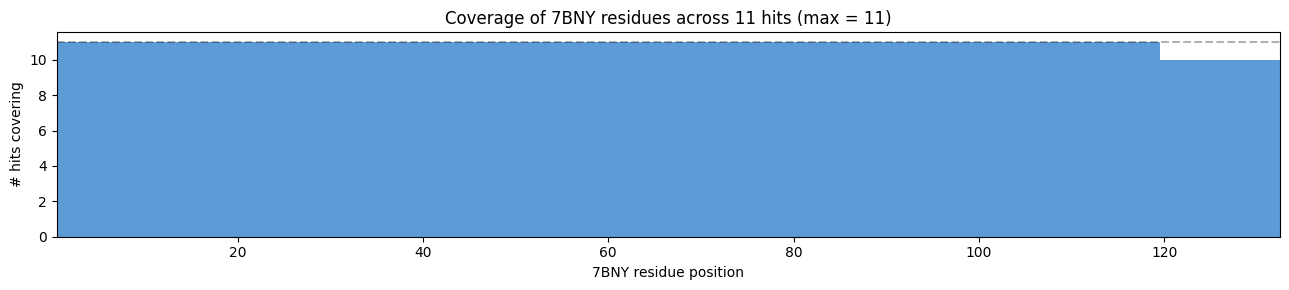

In [15]:
# Coverage chart: which positions are covered by how many hits
fig, ax = plt.subplots(figsize=(13, 3))
cov_count = np.zeros(target_len, dtype=int)
for v in hit_variants:
    for p in v["pos_map"]:
        cov_count[p - 1] += 1
ax.bar(range(1, target_len + 1), cov_count, color="#5C9BD5", width=1.0)
ax.set_xlabel("7BNY residue position")
ax.set_ylabel("# hits covering")
ax.set_title(f"Coverage of 7BNY residues across {len(hit_variants)} hits (max = {len(hit_variants)})")
ax.set_xlim(0.5, target_len + 0.5)
ax.axhline(len(hit_variants), color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()